In [2]:
%load_ext autoreload
%autoreload 2

import os
#set project root
notebook_dir = os.getcwd()
print("Current notebook directory:", notebook_dir)

# Risali di un livello (notebook → DEEP-CHEMOMETRICS)
project_root = os.path.abspath(os.path.join(notebook_dir, '../..'))

# Imposta la working directory
os.chdir(project_root)
print("Working directory impostata su:", os.getcwd())


Current notebook directory: c:\Users\localadmin\Documents\Progetti\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\notebook\Mango_Project_PAstis
Working directory impostata su: c:\Users\localadmin\Documents\Progetti\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics


In [3]:
import numpy as np
import scipy as sp
import pandas as pd
import torch 
import torch.utils.data as data_utils
import matplotlib.pyplot as plt
from torch import nn
from torch import optim
from torch.backends.mkl import verbose
from src import utils
from src.net import TMA_net, comparison_net
from src.training.training import Trainer
from src.utils.misc import TrainerConfig
from src.utils.misc import snv
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import train_test_split
from scipy.signal import savgol_filter
#from pyarrow import set_timezone_db_path


In [4]:
print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("CUDA device name:", torch.cuda.get_device_name(0))

CUDA available: True
Device count: 1
CUDA device name: NVIDIA RTX 2000 Ada Generation Laptop GPU


In [9]:
# load dataset Dario in .mat format

mango_original = pd.read_csv(r"data/dataset/Mango/NAnderson2020MendeleyMangoNIRData.csv", sep=',', header=0)
file = mango_original.copy()
print("Total number of sample: ", file.shape[0])

data = sp.io.loadmat("data/dataset/Mango/mango_dm_full_outlier_removed2.mat")
print(data.keys())

Total number of sample:  11691
dict_keys(['__header__', '__version__', '__globals__', 'DM_cal', 'DM_test', 'Sp_cal', 'Sp_test', 'wave', 'SP_all_test', 'SP_all_train'])


In [10]:
print(mango_original)



           Set  Season Region        Date        Type Cultivar  Pop Temp  \
0          Cal       1     NT   2/10/2015  Hard Green     Caly    2  Mid   
1          Cal       1     NT   2/10/2015  Hard Green     Caly    2  Mid   
2          Cal       1     NT   2/10/2015  Hard Green     Caly    2  Mid   
3          Cal       1     NT   2/10/2015  Hard Green     Caly    2  Mid   
4          Cal       1     NT   2/10/2015  Hard Green     Caly    2  Mid   
...        ...     ...    ...         ...         ...      ...  ...  ...   
11686  Val Ext       4    QLD  25/01/2019       Ripen       HG  112   No   
11687  Val Ext       4    QLD  25/01/2019       Ripen       HG  112   No   
11688  Val Ext       4    QLD  25/01/2019       Ripen       HG  112   No   
11689  Val Ext       4    QLD  25/01/2019       Ripen       HG  112   No   
11690  Val Ext       4    QLD  25/01/2019       Ripen       HG  112   No   

              DM  285  ...  1173  1176  1179  1182  1185  1188  1191  1194  \
0      16

In [11]:
X_spectra_Dario_cal = data['Sp_cal']
print("Number of CAL dataset with outlier removed",X_spectra_Dario_cal.shape[0])

X_spectra_Dario_test = data['Sp_test']
print("Number of Test dataset with outlier" , X_spectra_Dario_test.shape[0], " if removed should be 1413")


# find wavelength from `data["wave"]` and convert them to strings
wave_names = [str(int(w)) for w in data["wave"].flatten()]

# Extract the original DataFrame with only wavelength of interest
X_original_df = mango_original[wave_names]
print(X_original_df.head())

#Convert in array NumPy
X_original = X_original_df.to_numpy()

print("Shape all file with cutted wavelength:", X_original.shape)

Number of CAL dataset with outlier removed 9914
Number of Test dataset with outlier 1448  if removed should be 1413
        684       687       690       693       696       699       702  \
0 -0.187572 -0.271236 -0.351005 -0.418628 -0.471548 -0.510750 -0.538847   
1 -0.183253 -0.267107 -0.347271 -0.415050 -0.468100 -0.507443 -0.535537   
2 -0.240969 -0.313623 -0.381965 -0.439224 -0.483448 -0.515665 -0.538356   
3 -0.240610 -0.313087 -0.381506 -0.439003 -0.483402 -0.515663 -0.538322   
4  0.056370 -0.049269 -0.158413 -0.257995 -0.341550 -0.407727 -0.458308   

        705       708       711  ...       963       966       969       972  \
0 -0.558357 -0.572195 -0.582111  ... -0.291061 -0.283766 -0.277665 -0.276466   
1 -0.555035 -0.569050 -0.578928  ... -0.288114 -0.280321 -0.275603 -0.273691   
2 -0.553933 -0.564771 -0.572177  ... -0.285849 -0.278140 -0.273570 -0.270683   
3 -0.553813 -0.564752 -0.572182  ... -0.284648 -0.277382 -0.273996 -0.272173   
4 -0.496121 -0.524892 -0.546607  

In [12]:
#find row number of X_spectra_Dario_cal in X_original
row_numbers = []        
for i in range(X_spectra_Dario_cal.shape[0]):
    row_number = np.where((X_original == X_spectra_Dario_cal[i]).all(axis=1))[0]
    if row_number.size > 0:
        row_numbers.append(row_number[0])
    else:
        row_numbers.append(None)
# Stampa finale
if None in row_numbers:
    print("Cal: None in row")
else:
    print("Cal: All matched")

# Converti in array NumPy
row_numbers = np.array(row_numbers)

print("Row numbers for calibration spectra:", row_numbers, row_numbers.shape)

#find row number of X_spectra_Dario_test in X_original
row_numbers_test = []       
for i in range(X_spectra_Dario_test.shape[0]):
    row_number = np.where((X_original == X_spectra_Dario_test[i]).all(axis=1))[0]
    if row_number.size > 0:
        row_numbers_test.append(row_number[0])
    else:
        row_numbers_test.append(None)

# Converti in array NumPy
row_numbers_test = np.array(row_numbers_test)

# Stampa finale
if None in row_numbers_test:
    print("Test: None in row")
else:
    print("Test: All matched")

print("Row numbers for test spectra:", row_numbers_test, row_numbers_test.shape)

Cal: All matched
Row numbers for calibration spectra: [    0     1     2 ... 10240 10241 10242] (9914,)
Test: All matched
Row numbers for test spectra: [10243 10244 10245 ... 11688 11689 11690] (1448,)


In [13]:
# Extract from the original DataFrame only the rows corresponding to the spectra of Dario

X_mango_selected = mango_original.iloc[np.concatenate((row_numbers, row_numbers_test)), :]



In [14]:
# Find eventual replicates in the calibration spectra eand assign them a group label
# Replicate should have the same value of first 8 Dataframe columns

print(list(X_mango_selected.columns[:9]))
replicate_groups = X_mango_selected.groupby(list(X_mango_selected.columns[:9]),sort=False).ngroup()
print(replicate_groups[0:10]) # Print first 10 groups for brevity

['Set', 'Season', 'Region', 'Date', 'Type', 'Cultivar', 'Pop', 'Temp', 'DM']
0    0
1    0
2    1
3    1
4    2
5    2
6    3
7    3
8    4
9    4
dtype: int64


In [46]:
mask_123 = X_mango_selected["Season"].isin([1, 2, 3]).values
mask_4 = X_mango_selected["Season"].isin([4]).values

idx_all = np.arange(len(X_mango_selected))
idx_season123 = idx_all[mask_123]
idx_season4 = idx_all[mask_4]

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.333, random_state=42) 
train_idx_rel, val_idx_rel = next(gss1.split(idx_season123, y=None, groups=replicate_groups.iloc[idx_season123].to_numpy()))

test_idx = idx_season4

In [47]:
#Split in CAL, VAL and TEST
# Random split Season 1 - 2 - 3 for calibration
# Random split Season 1 - 2 - 3 for validation
# Season 4 for test
# Spectral range from 435 to 1050 nm
wave_range = [str(i) for i in range(435, 1051,3)]
train_idx = np.asarray(idx_season123[train_idx_rel], dtype=int)
val_idx   = np.asarray(idx_season123[val_idx_rel],   dtype=int)
test_idx  = np.asarray(test_idx, dtype=int)

X_cal  = X_mango_selected.loc[:, wave_range].iloc[train_idx].to_numpy()
y_cal  = X_mango_selected.iloc[train_idx][["DM"]].to_numpy()

X_val  = X_mango_selected.loc[:, wave_range].iloc[val_idx].to_numpy()
y_val  = X_mango_selected.iloc[val_idx][["DM"]].to_numpy()

X_test = X_mango_selected.loc[:, wave_range].iloc[test_idx].to_numpy()
y_test = X_mango_selected.iloc[test_idx][["DM"]].to_numpy()

In [48]:



# --- DataFrame "di appoggio" con sole colonne di metadata (non spettrali)
# Usa direttamente il df sorgente per leggere Date/Season/Region/Type
cal_df  = X_mango_selected.iloc[train_idx]
val_df  = X_mango_selected.iloc[val_idx]
test_df = X_mango_selected.iloc[test_idx]

print('\n## Short resume of the dataset')

# Full Dataset
print('Data set dimensions ----------------------------')
print(f'Wavelengths number = {len(wave_range)}')
print("")

# Calibration Dataset
years = pd.to_datetime(cal_df['Date'], dayfirst=True, errors='coerce').dt.year
print(f'Calibration set dims X Y = {X_cal.shape}\t{y_cal.shape}')
print(f'Year range: from {int(years.min()) if years.notna().any() else "NA"} to {int(years.max()) if years.notna().any() else "NA"}')
print(
    'Cal: Uniques',
    'Season', np.unique(cal_df['Season']),
    'Region', np.unique(cal_df['Region']),
    'Type',   np.unique(cal_df['Type']),
    'Cultivar', np.unique(cal_df['Cultivar'])
)
print("")

# Validation Dataset
years = pd.to_datetime(val_df['Date'], dayfirst=True, errors='coerce').dt.year
print(f'Validation set dims X Y = {X_val.shape}\t{y_val.shape}')
print(f'Year range: from {int(years.min()) if years.notna().any() else "NA"} to {int(years.max()) if years.notna().any() else "NA"}')
print(
    'Val: Uniques',
    'Season', np.unique(val_df['Season']),
    'Region', np.unique(val_df['Region']),
    'Type',   np.unique(val_df['Type']),
    'Cultivar', np.unique(val_df['Cultivar'])
)
print("")

# Test Dataset
years = pd.to_datetime(test_df['Date'], dayfirst=True, errors='coerce').dt.year
print(f'Test set dims X Y = {X_test.shape}\t{y_test.shape}')
print(f'Year range: from {int(years.min()) if years.notna().any() else "NA"} to {int(years.max()) if years.notna().any() else "NA"}')
print(
    'Test: Uniques',
    'Season', np.unique(test_df['Season']),
    'Region', np.unique(test_df['Region']),
    'Type',   np.unique(test_df['Type']),
    'Cultivar', np.unique(test_df['Cultivar'])
)




## Short resume of the dataset
Data set dimensions ----------------------------
Wavelengths number = 206

Calibration set dims X Y = (6608, 206)	(6608, 1)
Year range: from 2015 to 2018
Cal: Uniques Season [1 2 3] Region ['NT' 'QLD'] Type ['Hard Green' 'Ripen'] Cultivar ['1201' '1243' '4069' 'Caly' 'HG' 'KP' 'Keitt' 'LadyG' 'LadyJ' 'R2E2']

Validation set dims X Y = (3306, 206)	(3306, 1)
Year range: from 2015 to 2018
Val: Uniques Season [1 2 3] Region ['NT' 'QLD'] Type ['Hard Green' 'Ripen'] Cultivar ['1201' '1243' '4069' 'Caly' 'HG' 'KP' 'Keitt' 'LadyG' 'LadyJ' 'R2E2']

Test set dims X Y = (1448, 206)	(1448, 1)
Year range: from 2018 to 2019
Test: Uniques Season [4] Region ['NT' 'QLD'] Type ['Hard Green' 'Ripen'] Cultivar ['Caly' 'HG' 'KP' 'R2E2']


In [36]:
A = 'Type'
Cult = 'HG'

print(cal_df.loc[cal_df['Cultivar'].isin([Cult]), A].unique())
print(val_df.loc[val_df['Cultivar'].isin([Cult]), A].unique())
print(test_df.loc[test_df['Cultivar'].isin([Cult]), A].unique())
print('')
print(cal_df.loc[cal_df['Cultivar'].isin(['KP']), A].unique())
print(val_df.loc[val_df['Cultivar'].isin(['KP']), A].unique())
print(test_df.loc[test_df['Cultivar'].isin(['KP']), A ].unique())

['Hard Green' 'Ripen']
['Hard Green' 'Ripen']
['Hard Green' 'Ripen']

['Hard Green' 'Ripen']
['Hard Green' 'Ripen']
['Hard Green' 'Ripen']


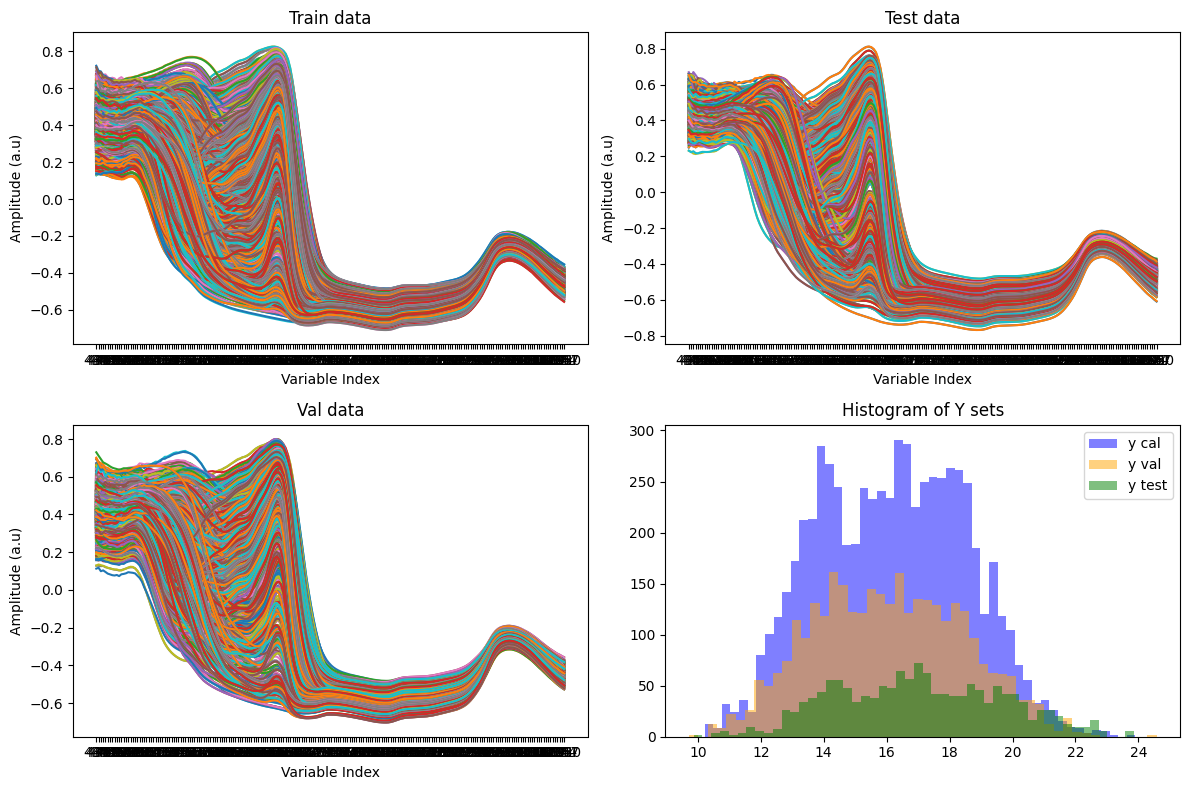

In [37]:

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Subplot (2,2,1) - Train
axs[0, 0].set_title('Train data')
axs[0, 0].plot(wave_range, X_cal.T)
axs[0, 0].set_ylabel('Amplitude (a.u)')
axs[0, 0].set_xlabel('Variable Index')

# Subplot (2,2,2) - Test
axs[0, 1].set_title('Test data')
axs[0, 1].plot(wave_range, X_test.T)
axs[0, 1].set_ylabel('Amplitude (a.u)')
axs[0, 1].set_xlabel('Variable Index')

# Subplot (2,2,3) - Val
axs[1, 0].set_title('Val data')
axs[1, 0].plot(wave_range, X_val.T)
axs[1, 0].set_ylabel('Amplitude (a.u)')
axs[1, 0].set_xlabel('Variable Index')

# Subplot (2,2,4) - Istogrammi sovrapposti
axs[1, 1].hist(y_cal, bins=50, alpha=0.5, label='y cal', color='blue')
axs[1, 1].hist(y_val, bins=50, alpha=0.5, label='y val', color='orange')
axs[1, 1].hist(y_test, bins=50, alpha=0.5, label='y test', color='green')
axs[1, 1].set_title('Histogram of Y sets')
axs[1, 1].legend()

plt.tight_layout()
plt.show()


In [49]:
# Preprocessing Dataset
# SNV - Savitzky-Golay derivative 1st and 2nd order - combination of SNV and SG


SG_Width = 13
SG_poly = 2

X_cal_snv = snv(X_cal)
X_val_snv = snv(X_val)
X_test_snv = snv(X_test)

X_cal_SG1 = savgol_filter(X_cal, SG_Width, SG_poly, deriv = 1,axis=1)
X_val_SG1 = savgol_filter(X_val, SG_Width, SG_poly, deriv = 1,axis=1)
X_test_SG1 = savgol_filter(X_test, SG_Width, SG_poly, deriv = 1,axis=1)


X_cal_SG2 = savgol_filter(X_cal, SG_Width, SG_poly, deriv = 2,axis=1)
X_val_SG2 = savgol_filter(X_val, SG_Width, SG_poly, deriv = 2,axis=1)
X_test_SG2= savgol_filter(X_test, SG_Width, SG_poly, deriv = 2,axis=1)

X_cal_snv_SG1 = savgol_filter(X_cal_snv, SG_Width, SG_poly, deriv = 1,axis=1)
X_val_snv_SG1 = savgol_filter(X_val_snv, SG_Width, SG_poly, deriv = 1,axis=1)
X_test_snv_SG1 = savgol_filter(X_test_snv, SG_Width, SG_poly, deriv = 1,axis=1)

X_cal_snv_SG2 = savgol_filter(X_cal_snv, SG_Width, SG_poly, deriv = 2,axis=1)
X_val_snv_SG2 = savgol_filter(X_val_snv, SG_Width, SG_poly, deriv = 2,axis=1)
X_test_snv_SG2= savgol_filter(X_test_snv, SG_Width, SG_poly, deriv = 2,axis=1)

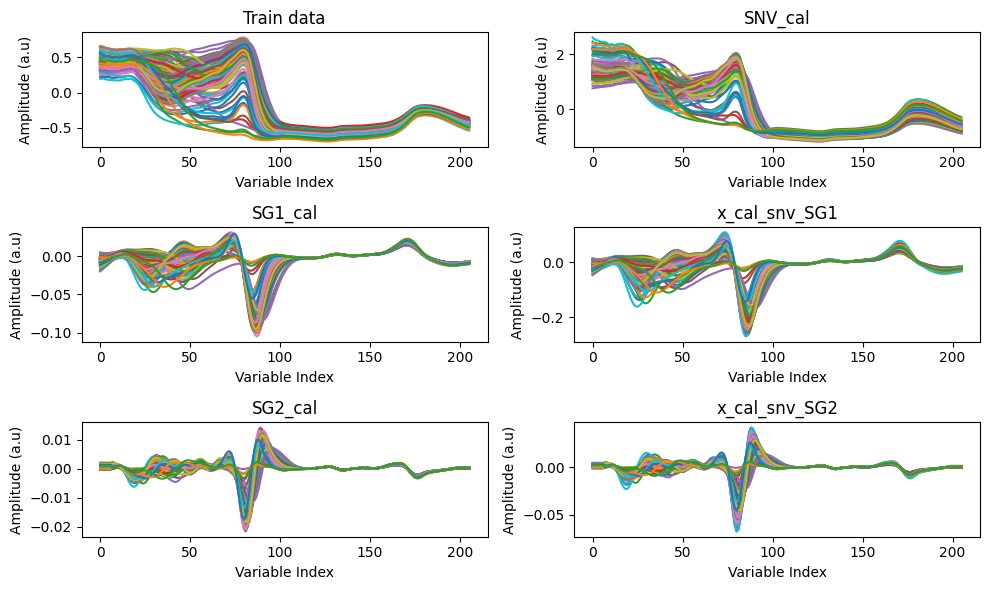

In [39]:
plt.figure(figsize=(10,6))
plt.subplot(321)
plt.title('Train data')
plt.plot(X_cal[::50,:].T)
plt.ylabel('Amplitude (a.u)')
plt.xlabel('Variable Index')
plt.subplot(322)
plt.title('SNV_cal')
plt.plot(X_cal_snv[::50,:].T)
plt.ylabel('Amplitude (a.u)')
plt.xlabel('Variable Index')
plt.subplot(323)
plt.title('SG1_cal')
plt.plot(X_cal_SG1[::50,:].T)
plt.ylabel('Amplitude (a.u)')
plt.xlabel('Variable Index')
plt.subplot(324)
plt.title('x_cal_snv_SG1')
plt.plot(X_cal_snv_SG1[::50,:].T)
plt.ylabel('Amplitude (a.u)')
plt.xlabel('Variable Index')
plt.subplot(325)
plt.title('SG2_cal')
plt.plot(X_cal_SG2[::50,:].T)
plt.ylabel('Amplitude (a.u)')
plt.xlabel('Variable Index')
plt.subplot(326)
plt.title('x_cal_snv_SG2')
plt.plot(X_cal_snv_SG2[::50,:].T)
plt.ylabel('Amplitude (a.u)')
plt.xlabel('Variable Index')
plt.tight_layout()
plt.show()


In [50]:
# create trainer config
model_name ="Train_Mango"
config = TrainerConfig(model_name = model_name)
config.update_config(batch_size=1024,learning_rate=0.01,num_epochs=1000,classification=False,max_loss_plot=20)
print(config)

TrainerConfig(batch_size=1024, learning_rate=0.01, num_epochs=1000, device=cuda, save_model=True,  classification=False, max_loss_plot=20,save_path=C:\Users\localadmin\Documents\Progetti\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\Train_Mango)


Start comparison

1) Raw data + ccn + FCC 
2) concatenated preprocessed data + ccn + FFC
3) Pastis net

1) Raw data

Optimization of Kernel size - Number of Filter - FC neurons - Dropout by DoE

In [18]:
# Convert np.array to Dataloader 
# add dt in loader 

cal1 = data_utils.TensorDataset(torch.Tensor(X_cal), torch.Tensor(y_cal))
cal_loader1 = data_utils.DataLoader(cal1, batch_size=config.batch_size, shuffle=True)

val1 = data_utils.TensorDataset(torch.Tensor(X_val), torch.Tensor(y_val))
val_loader1 = data_utils.DataLoader(val1, batch_size=config.batch_size, shuffle=False)

test_dt1 = data_utils.TensorDataset(torch.Tensor(X_test), torch.Tensor(y_test))
test_loader1 = data_utils.DataLoader(test_dt1, batch_size=config.batch_size, shuffle=False)

In [27]:
# # import DoE experiment

Doe_run = pd.read_csv(r"data\dataset\Mango\DoE_TMA_Net\Albania\run\DoE_InteractionquadraticDoE_net1.csv",delimiter=';',decimal=",").to_dict(orient='records')
print(Doe_run[1])

results_dict1 = {}
selected_indices = list(range(len(Doe_run)))
print("Selected indices for DoE experiment:", selected_indices)

{'Exp No': 2, 'Exp Name': 'N2', 'Run Order': 52, 'Incl/Excl': 'Incl', 'kernel_size': 5, 'n_filters': 1, 'fc_dim1': 32, 'dropout': 0.1, 'MSE': 0.522401, 'R2': 0.909817}
Selected indices for DoE experiment: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80]


In [28]:
# Run DoE experiment
# selcted_point = [3,12]
# selcted_indices = [x for i in selcted_point for x in (i, i+27, i+54)]
# selcted_indices = [30]
# selected_indices = [ i -1 for i in selcted_indices]
# print("Selected indices for DoE experiment:", selected_indices)


# Run DoE experiment solo per quelle righe
for i in selected_indices:
    run = Doe_run[i]
    print(f"Running experiment: {run['Exp Name']}")  
    model_name = f"DOE2_comparison_net1_Mango{run['Exp Name']}"
    config = TrainerConfig(model_name = model_name)
    config.update_config(batch_size=1024,learning_rate=0.01,num_epochs=1000,classification=False,max_loss_plot=20)

    # Define model
    model = comparison_net(
        input_dims = X_cal.shape[1],
        mean = np.mean(X_cal, axis=0),
        std = np.std(X_cal, axis=0),
        n_filters = run['n_filters'],
        kernel_size = run['kernel_size'],
        fc1_dims = run['fc_dim1'],
        dropout= run['dropout'],
        out_dims=1
    )

    #print(model)

    optimizer = optim.Adam(model.parameters(), lr=config.learning_rate, weight_decay=0.003/2)
    criterion = nn.MSELoss(reduction='none')
    trainer = Trainer(
        model=model,
        optimizer=optimizer,
        criterion=criterion,
        train_loader=cal_loader1,
        val_loader=val_loader1,
        config=config,
        r_metric='r2',
        verbose=False,
    )
    train_losses, val_losses,val_r2_scores, final_path = trainer.train()
    results_dict1[run["Exp Name"]] = {
        "Final Val MSE": val_losses[-1].item(),
        "Final Val R²": float(np.mean(val_r2_scores[-1]))
        }
    print(f"Training completed for {model_name}. Final path: {final_path}")


Running experiment: N1
Training completed for DOE2_comparison_net1_MangoN1. Final path: C:\Users\localadmin\Documents\Progetti\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\DOE2_comparison_net1_MangoN1_best.pth
Running experiment: N2
Training completed for DOE2_comparison_net1_MangoN2. Final path: C:\Users\localadmin\Documents\Progetti\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\DOE2_comparison_net1_MangoN2_best.pth
Running experiment: N3
Training completed for DOE2_comparison_net1_MangoN3. Final path: C:\Users\localadmin\Documents\Progetti\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\DOE2_comparison_net1_MangoN3_best.pth
Running experiment: N4
Training completed for DOE2_comparison_net1_MangoN4. Final path: C:\Users\localadmin\Documents\Progetti\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\DOE2_comparison_net1_MangoN4_best.pth
Running experiment: N5
Training completed for DOE2_comparison_net1_MangoN5. Final path: 

In [29]:
df_results = pd.DataFrame.from_dict(results_dict1, orient='index').reset_index()
df_results.rename(columns={'index': 'Exp Name'}, inplace=True)
print(df_results)

   Exp Name  Final Val MSE  Final Val R²
0        N1       0.600606      0.896316
1        N2       0.606413      0.895314
2        N3       0.634254      0.890508
3        N4       0.472296      0.918467
4        N5       0.922218      0.840796
..      ...            ...           ...
76      N77       3.646548      0.370489
77      N78       0.664788      0.885236
78      N79       0.488594      0.915653
79      N80       0.644696      0.888705
80      N81       0.538210      0.907088

[81 rows x 3 columns]


In [30]:
df_results.to_csv("data/dataset/Mango/DoE_TMA_Net/Albania/DoE_results_InteractionquadraticDoE_net1.csv", index=False,sep=';', decimal='.')

comparison_net(
  (dropout): Dropout(p=0.1, inplace=False)
  (conv1d): Conv1d(1, 3, kernel_size=(5,), stride=(1,), padding=same)
  (fc1): Linear(in_features=618, out_features=52, bias=True)
  (fc2): Linear(in_features=52, out_features=26, bias=True)
  (fc3): Linear(in_features=26, out_features=13, bias=True)
  (out): Linear(in_features=13, out_features=1, bias=True)
)
Saving best model to C:\Users\localadmin\Documents\Progetti\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\DOE2_comparison_net1_MangoN81_best.pth
Epoch 1/1000 | Train Loss: 279.0694 | Val Loss: 76.2940 | Val Mean Metrics: -12.1708
Model saved at epoch 0 to C:\Users\localadmin\Documents\Progetti\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\DOE2_comparison_net1_MangoN81_best.pth
Model saved at epoch 0 to C:\Users\localadmin\Documents\Progetti\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\DOE2_comparison_net1_MangoN81_best.pth
Epoch 2/1000 | Train Loss: 58.9908 | Val Loss: 2

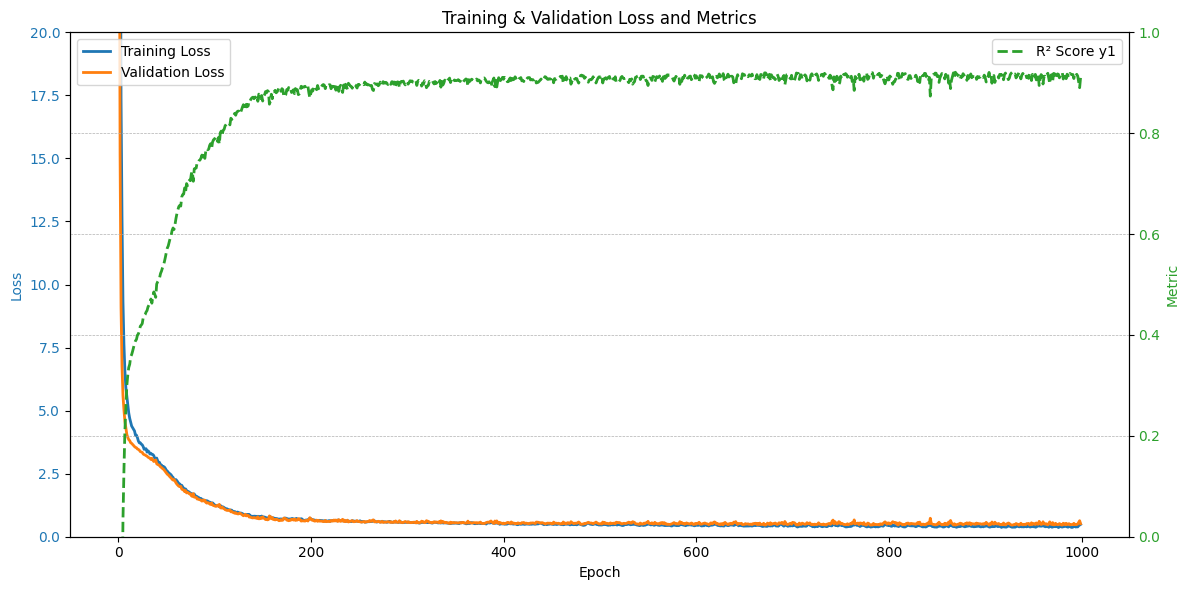

Training completed for net1_Mango2_optimalconditions. Final path: C:\Users\localadmin\Documents\Progetti\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\DOE2_comparison_net1_MangoN81_best.pth
tensor([0.4580])
CCC: 0.9325019057554456, R2: 0.8812791109085083, RMSEP: 0.9194878935813904


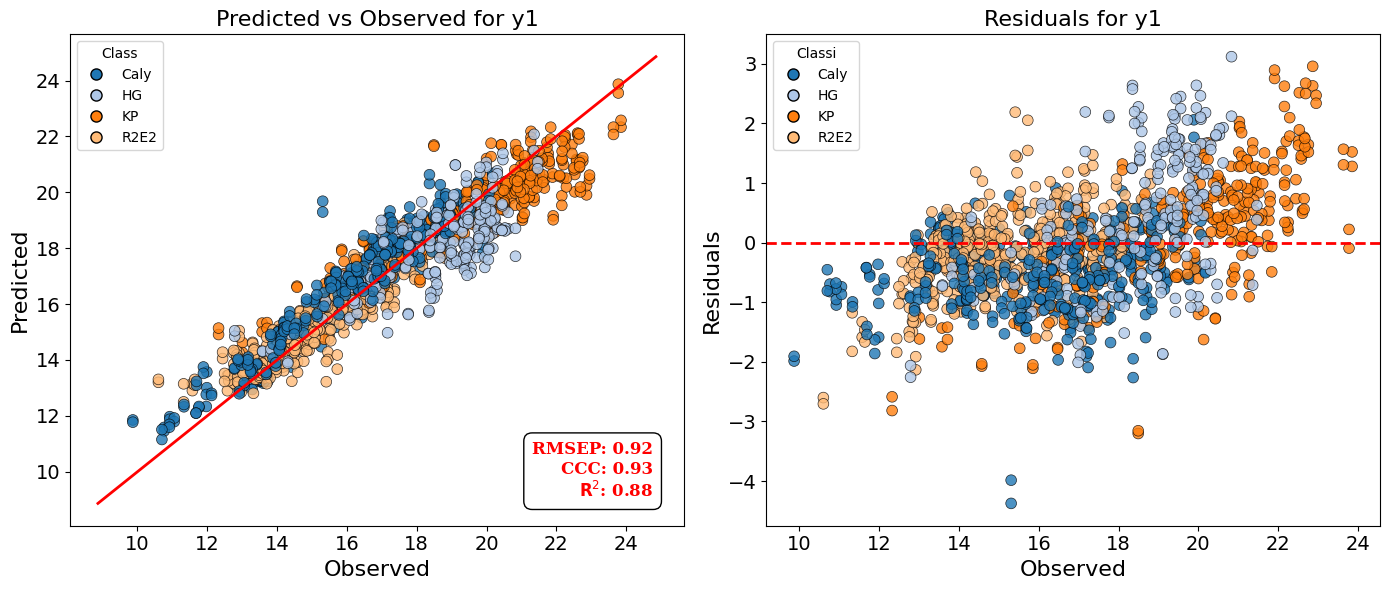

In [31]:
model_name = "net1_Mango2_optimalconditions"
config.model_name = model_name
model = comparison_net(
        input_dims = X_cal.shape[1],
        mean = np.mean(X_cal, axis=0),
        std = np.std(X_cal, axis=0),
        n_filters = 3,
        kernel_size = 5,
        fc1_dims = 52,
        dropout= 0.1,
        out_dims=1
    )
config.num_epochs = 1000


optimizer = optim.Adam(model.parameters(), lr=config.learning_rate, weight_decay=0.003/2)
criterion = nn.MSELoss(reduction='none')
print(model)

trainer = Trainer(model=model, optimizer=optimizer, criterion=criterion, train_loader=cal_loader1, val_loader=val_loader1, config=config,verbose=True)

train_losses, val_losses,val_r2_scores, final_path = trainer.train()
print(f"Training completed for {model_name}. Final path: {final_path}")

print(min(val_losses))
utils.test(model, final_path, test_loader1,config, Residual=True , classes= test_df[ "Cultivar"] )

In [32]:
total = 0
print("Nombre de paramètres par couche :")
for nom, param in model.named_parameters():
    if param.requires_grad:
        nb_params = param.numel()
        print(f"{nom}: {nb_params}")
        total += nb_params

print(f"\nNombre total de paramètres : {total}")

Nombre de paramètres par couche :
conv1d.weight: 15
conv1d.bias: 3
fc1.weight: 32136
fc1.bias: 52
fc2.weight: 1352
fc2.bias: 26
fc3.weight: 338
fc3.bias: 13
out.weight: 13
out.bias: 1

Nombre total de paramètres : 33949


2) Startegie 2

In [33]:
X_cal_concat1 = np.concatenate((X_cal, X_cal_snv, X_cal_SG1, X_cal_SG2, X_cal_snv_SG1, X_cal_snv_SG2), axis=1)
X_val_concat1 = np.concatenate((X_val, X_val_snv, X_val_SG1, X_val_SG2, X_val_snv_SG1, X_val_snv_SG2), axis=1)
X_test_concat1 = np.concatenate((X_test, X_test_snv, X_test_SG1, X_test_SG2, X_test_snv_SG1, X_test_snv_SG2), axis=1)

print("Xcal_concat:", X_cal_concat1.shape)
print("y_cal:", y_cal.shape)


Xcal_concat: (6608, 1236)
y_cal: (6608, 1)


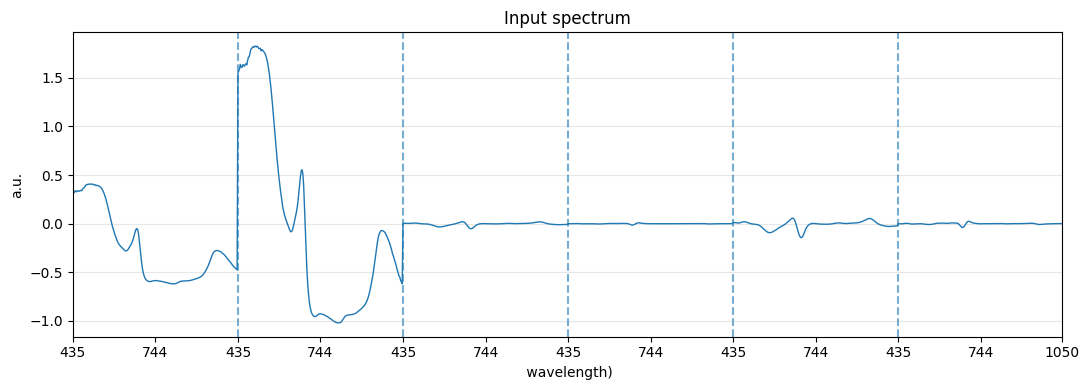

len(wave_range) = 206, n_vars = 1236, n_blocks stimati = 6 (esatti = 6, resto = 0)
Breakpoints (inizio nuovi preprocessing): [206, 412, 618, 824, 1030]


In [96]:
# --- Parametri rapidi ---
xtick_step = 103      # un tick ogni 100 variabili

# --- Prendi primo spettro e controlli ---
x_arr = np.asarray(X_cal_concat1)
wave_raw = np.asarray(wave_range, dtype=float)

x = x_arr[0] if x_arr.ndim == 2 else x_arr
n_vars = x.shape[-1]
L = wave_raw.shape[0]

if L == 0:
    raise ValueError("wave_range è vuoto.")
    
# --- Ricostruisci l'asse 'wave' per il concatenato ---
# Ripeti wave_range fino a coprire n_vars (e tronca se l'ultimo blocco è parziale)
n_blocks_exact = n_vars // L
remainder = n_vars % L
n_blocks = n_blocks_exact if remainder == 0 else n_blocks_exact + 1
wave_concat = np.tile(wave_raw, n_blocks)[:n_vars]

# --- Breakpoints: confini tra preprocessing (multipli di L) ---
breakpoints = [i * L for i in range(1, n_blocks_exact)]  # non include l'ultimo bordo se blocco parziale

# --- Plot ---
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(np.arange(n_vars), x, linewidth=1)
ax.set_title("Input spectrum")
ax.set_xlabel(" wavelength)")
ax.set_ylabel("a.u.")

# linee verticali ai cambi preprocessing
for b in breakpoints:
    ax.axvline(b, linestyle="--", alpha=0.6)

# xticks ogni N punti con etichette = wavelength corrispondente (dal wave_concat ricostruito)
ticks = np.arange(0, n_vars, xtick_step)
ticks = np.append(ticks,(X_cal_concat1.shape[1]-1))  # assicurati che l'ultimo punto sia incluso
ax.set_xticks(ticks)
ax.set_xticklabels([f"{wave_concat[i]:g}" for i in ticks])

ax.set_xlim(0, n_vars - 1)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"len(wave_range) = {L}, n_vars = {n_vars}, n_blocks stimati = {n_blocks} (esatti = {n_blocks_exact}, resto = {remainder})")
print("Breakpoints (inizio nuovi preprocessing):", breakpoints)

# --- (Opzionale) Nomi dei preprocessing per annotare i blocchi ---
# Se definisci prima: preproc_names = ["raw", "SNV", "1st der", ...]
# verranno scritti sopra i rispettivi segmenti.
preproc_names = locals().get("preproc_names", None)
if preproc_names and len(preproc_names) >= n_blocks:
    ymin, ymax = ax.get_ylim()
    for k in range(n_blocks):
        start = k * L
        end = min((k + 1) * L, n_vars)
        xc = (start + end) / 2
        ax.text(xc, ymax, preproc_names[k], ha="center", va="bottom", fontsize=9)
    plt.draw()

In [35]:
# Convert np.array to Dataloader 
# add dt in loader 

cal2 = data_utils.TensorDataset(torch.Tensor(X_cal_concat1), torch.Tensor(y_cal))
cal_loader2 = data_utils.DataLoader(cal2, batch_size=config.batch_size, shuffle=True)

val2 = data_utils.TensorDataset(torch.Tensor(X_val_concat1), torch.Tensor(y_val))
val_loader2 = data_utils.DataLoader(val2, batch_size=config.batch_size, shuffle=False)

test_dt2 = data_utils.TensorDataset(torch.Tensor(X_test_concat1), torch.Tensor(y_test))
test_loader2 = data_utils.DataLoader(test_dt2, batch_size=config.batch_size, shuffle=False)

In [36]:
# import DoE experiment

Doe_run = pd.read_csv(r"data\dataset\Mango\DoE_TMA_Net\Albania\run\DoE_InteractionquadraticDoE_net1.csv",delimiter=';',decimal=",").to_dict(orient='records')
print(Doe_run[1])

results_dict2 = {}
selected_indices = list(range(len(Doe_run)))
print("Selected indices for DoE experiment:", selected_indices)

{'Exp No': 2, 'Exp Name': 'N2', 'Run Order': 52, 'Incl/Excl': 'Incl', 'kernel_size': 5, 'n_filters': 1, 'fc_dim1': 32, 'dropout': 0.1, 'MSE': 0.522401, 'R2': 0.909817}
Selected indices for DoE experiment: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80]


In [37]:
# Run DoE experiment
# selcted_point = [9]
# selcted_indices = [x for i in selcted_point for x in (i, i+27, i+54)]
# selected_indices = [ i -1 for i in selcted_indices]
# print("Selected indices for DoE experiment:", selected_indices)


# Run DoE experiment solo per quelle righe
for i in selected_indices:
    run = Doe_run[i]
    print(f"Running experiment: {run['Exp Name']}")    
    model_name = f"DOE2_comparison_net2_Mango{run['Exp Name']}"
    config = TrainerConfig(model_name = model_name)
    config.update_config(batch_size=1024,learning_rate=0.01,num_epochs=1000,classification=False,max_loss_plot=20)

    # Define model
    model = comparison_net(
        input_dims = X_cal_concat1.shape[1],
        mean = np.mean(X_cal_concat1, axis=0),
        std = np.std(X_cal_concat1, axis=0),
        n_filters = run['n_filters'],
        kernel_size = run['kernel_size'],
        fc1_dims = run['fc_dim1'],
        dropout= run['dropout'],
        out_dims=1
    )

    #print(model)

    optimizer = optim.Adam(model.parameters(), lr=config.learning_rate, weight_decay=0.003/2)
    criterion = nn.MSELoss(reduction='none')
    trainer = Trainer(
        model=model,
        optimizer=optimizer,
        criterion=criterion,
        train_loader=cal_loader2,
        val_loader=val_loader2,
        config=config,
        r_metric='r2',
        verbose=False,
    )
    train_losses, val_losses,val_r2_scores, final_path = trainer.train()
    results_dict2[run["Exp Name"]] = {
        "Final Val MSE": val_losses[-1].item(),
        "Final Val R²": float(np.mean(val_r2_scores[-1]))
        }
    print(f"Training completed for {model_name}. Final path: {final_path}")


Running experiment: N1
Training completed for DOE2_comparison_net2_MangoN1. Final path: C:\Users\localadmin\Documents\Progetti\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\DOE2_comparison_net2_MangoN1_best.pth
Running experiment: N2
Training completed for DOE2_comparison_net2_MangoN2. Final path: C:\Users\localadmin\Documents\Progetti\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\DOE2_comparison_net2_MangoN2_best.pth
Running experiment: N3
Training completed for DOE2_comparison_net2_MangoN3. Final path: C:\Users\localadmin\Documents\Progetti\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\DOE2_comparison_net2_MangoN3_best.pth
Running experiment: N4
Training completed for DOE2_comparison_net2_MangoN4. Final path: C:\Users\localadmin\Documents\Progetti\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\DOE2_comparison_net2_MangoN4_best.pth
Running experiment: N5
Training completed for DOE2_comparison_net2_MangoN5. Final path: 

In [38]:
df_results = pd.DataFrame.from_dict(results_dict2, orient='index').reset_index()
df_results.rename(columns={'index': 'Exp Name'}, inplace=True)
print(df_results)

   Exp Name  Final Val MSE  Final Val R²
0        N1       0.497975      0.914034
1        N2       0.447326      0.922777
2        N3       0.496714      0.914251
3        N4       0.669260      0.884464
4        N5       0.468666      0.919093
..      ...            ...           ...
76      N77       0.453144      0.921773
77      N78       0.560980      0.903157
78      N79       0.569169      0.901743
79      N80       0.481287      0.916914
80      N81       0.466458      0.919474

[81 rows x 3 columns]


In [39]:
df_results.to_csv("data/dataset/Mango/DoE_TMA_Net/Albania/DoE_results_InteractionquadraticDoE_net2.csv", index=False,sep=';', decimal='.')

comparison_net(
  (dropout): Dropout(p=0.1, inplace=False)
  (conv1d): Conv1d(1, 2, kernel_size=(5,), stride=(1,), padding=same)
  (fc1): Linear(in_features=2472, out_features=76, bias=True)
  (fc2): Linear(in_features=76, out_features=38, bias=True)
  (fc3): Linear(in_features=38, out_features=19, bias=True)
  (out): Linear(in_features=19, out_features=1, bias=True)
)
Saving best model to C:\Users\localadmin\Documents\Progetti\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\DOE2_comparison_net2_MangoN81_best.pth
Epoch 1/1000 | Train Loss: 346.2115 | Val Loss: 61.2266 | Val Mean Metrics: -9.5697
Model saved at epoch 0 to C:\Users\localadmin\Documents\Progetti\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\DOE2_comparison_net2_MangoN81_best.pth
Model saved at epoch 0 to C:\Users\localadmin\Documents\Progetti\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\DOE2_comparison_net2_MangoN81_best.pth
Epoch 2/1000 | Train Loss: 56.8681 | Val Loss: 2

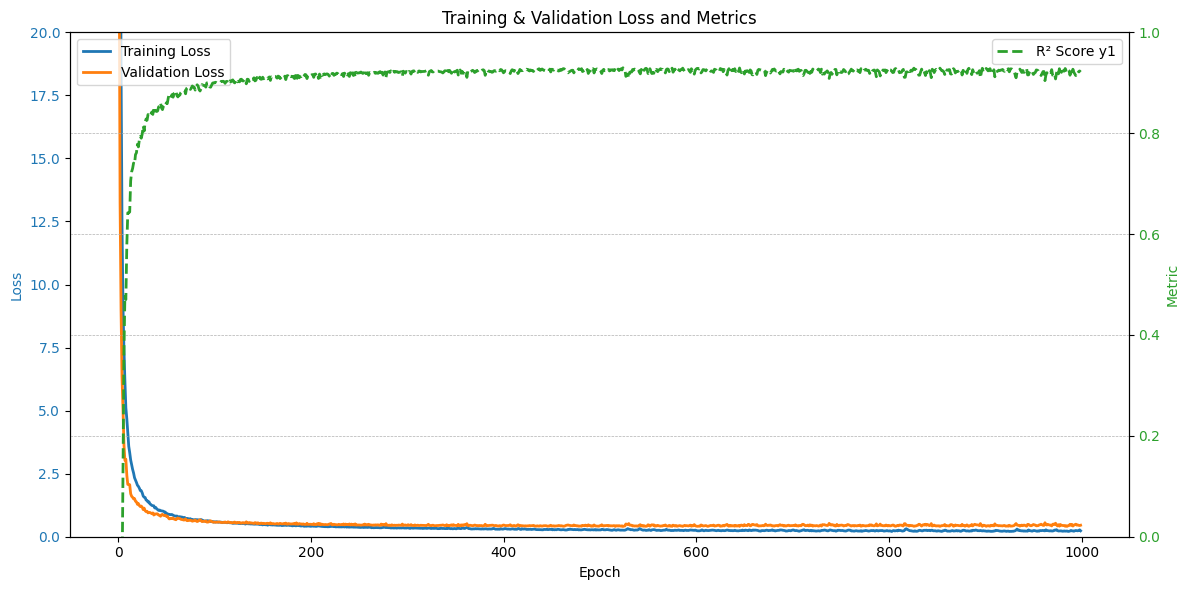

Training completed for net2_Mango2_optimalconditions. Final path: C:\Users\localadmin\Documents\Progetti\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\DOE2_comparison_net2_MangoN81_best.pth
tensor([0.4072])
CCC: 0.9376865200256344, R2: 0.8894457221031189, RMSEP: 0.8872994780540466


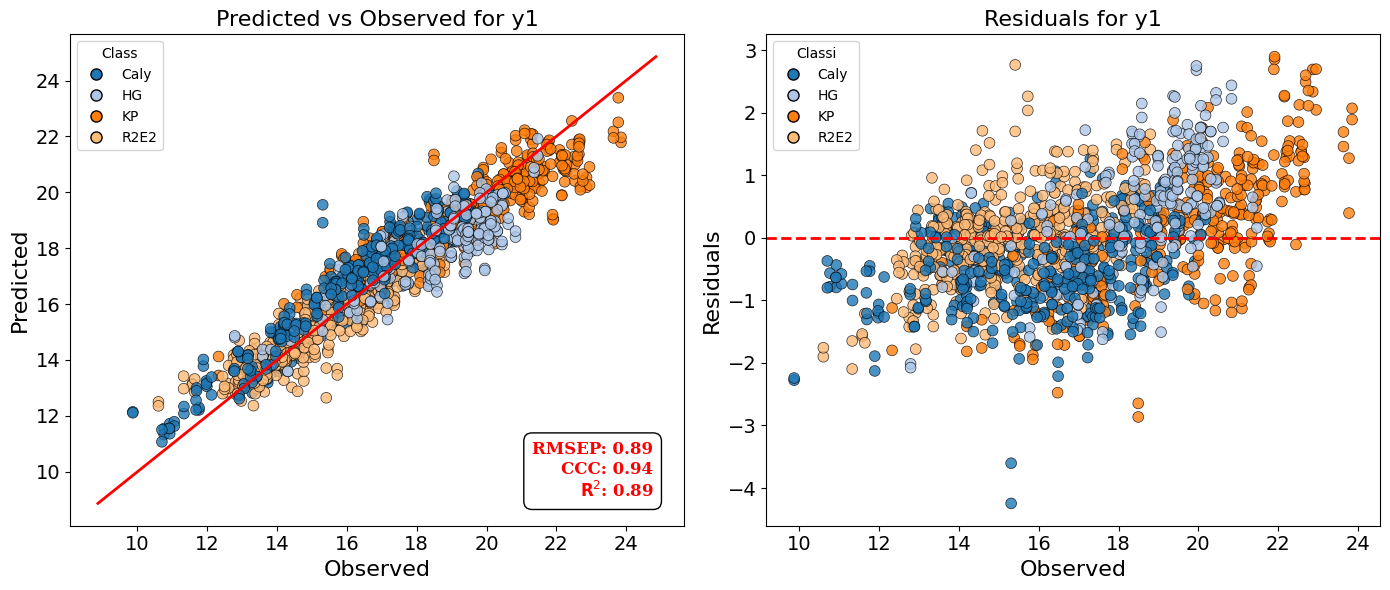

In [40]:
model_name = "net2_Mango2_optimalconditions"
config.model_name = model_name
model = comparison_net(
        input_dims = X_cal_concat1.shape[1],
        mean = np.mean(X_cal_concat1, axis=0),
        std = np.std(X_cal_concat1, axis=0),
        n_filters = 2,
        kernel_size = 5,
        fc1_dims = 76,
        dropout= 0.1,
        out_dims=1
    )
config.num_epochs = 1000


optimizer = optim.Adam(model.parameters(), lr=config.learning_rate, weight_decay=0.003/2)
criterion = nn.MSELoss(reduction='none')
print(model)

trainer = Trainer(
        model=model,
        optimizer=optimizer,
        criterion=criterion,
        train_loader=cal_loader2,
        val_loader=val_loader2,
        config=config,
        r_metric='r2',
        verbose=True,
    )
train_losses, val_losses,val_r2_scores, final_path = trainer.train()
print(f"Training completed for {model_name}. Final path: {final_path}")

print(min(val_losses))
utils.test(model, final_path, test_loader2,config, Residual=True, classes = test_df[ "Cultivar"] )

In [41]:
total = 0
print("Nombre de paramètres par couche :")
for nom, param in model.named_parameters():
    if param.requires_grad:
        nb_params = param.numel()
        print(f"{nom}: {nb_params}")
        total += nb_params

print(f"\nNombre total de paramètres : {total}")

Nombre de paramètres par couche :
conv1d.weight: 10
conv1d.bias: 2
fc1.weight: 187872
fc1.bias: 76
fc2.weight: 2888
fc2.bias: 38
fc3.weight: 722
fc3.bias: 19
out.weight: 19
out.bias: 1

Nombre total de paramètres : 191647


3) PASTIS NET

In [51]:
# Concatenate the preprocessed data
# unsqueeze the data to add a channel dimension
X_cal_e = np.expand_dims(X_cal, axis=2)
X_val_e = np.expand_dims(X_val, axis=2)
X_test_e = np.expand_dims(X_test, axis=2)

X_cal_snv_e = np.expand_dims(X_cal_snv, axis=2)
X_val_snv_e = np.expand_dims(X_val_snv, axis=2)
X_test_snv_e = np.expand_dims(X_test_snv, axis=2)

X_cal_SG1_e = np.expand_dims(X_cal_SG1, axis=2)
X_val_SG1_e = np.expand_dims(X_val_SG1, axis=2)
X_test_SG1_e = np.expand_dims(X_test_SG1, axis=2)

X_cal_SG2_e = np.expand_dims(X_cal_SG2, axis=2)
X_val_SG2_e = np.expand_dims(X_val_SG2, axis=2)
X_test_SG2_e = np.expand_dims(X_test_SG2, axis=2)

X_cal_snv_SG1_e = np.expand_dims(X_cal_snv_SG1, axis=2)
X_val_snv_SG1_e = np.expand_dims(X_val_snv_SG1, axis=2)
X_test_snv_SG1_e = np.expand_dims(X_test_snv_SG1, axis=2)

X_cal_snv_SG2_e = np.expand_dims(X_cal_snv_SG2, axis=2)
X_val_snv_SG2_e = np.expand_dims(X_val_snv_SG2, axis=2)
X_test_snv_SG2_e = np.expand_dims(X_test_snv_SG2, axis=2)
# Concatenate the data along the channel dimension
X_cal_concat2 = np.concatenate((X_cal_e, X_cal_snv_e, X_cal_SG1_e, X_cal_SG2_e, X_cal_snv_SG1_e, X_cal_snv_SG2_e), axis=2)
X_val_concat2 = np.concatenate((X_val_e, X_val_snv_e, X_val_SG1_e, X_val_SG2_e, X_val_snv_SG1_e, X_val_snv_SG2_e), axis=2)
X_test_concat2 = np.concatenate((X_test_e, X_test_snv_e, X_test_SG1_e, X_test_SG2_e, X_test_snv_SG1_e, X_test_snv_SG2_e), axis=2)
print("Xcal_concat shape:", X_cal_concat2.shape)
print("Xval_concat shape:", X_val_concat2.shape)
print("Xtest_concat shape:", X_test_concat2.shape) 

## Reshape according Torch training requirements
X_cal_concat2 = X_cal_concat2.transpose(0, 2, 1)  # Transpose to (samples, channels, features)
X_val_concat2 = X_val_concat2.transpose(0, 2, 1)  # Transpose to (samples, channels, features)
X_test_concat2 = X_test_concat2.transpose(0, 2, 1)  # Transpose to (samples, channels, features)

## Check for dimensions
print('Data set dimensions ----------------------------')
print('Full Train set dims X Y = {}\t{}'.format(X_cal_concat2.shape, y_cal.shape))
print('Test set dims X Y = {}\t{}'.format(X_test_concat2.shape, y_test.shape))

# calculate mean and std per column

mean = np.mean(X_cal_concat2, axis=0)
std = np.std(X_cal_concat2, axis=0)
print("Mean shape:", mean.shape)
print("Std shape:", std.shape)

# Autoscaling Input data

X_cal_std = (X_cal_concat2 - mean) / std
X_val_std = (X_val_concat2 - mean) / std    
X_test_std = (X_test_concat2 - mean) / std

print("X_cal_std:", X_cal_std.shape)

Xcal_concat shape: (6608, 206, 6)
Xval_concat shape: (3306, 206, 6)
Xtest_concat shape: (1448, 206, 6)
Data set dimensions ----------------------------
Full Train set dims X Y = (6608, 6, 206)	(6608, 1)
Test set dims X Y = (1448, 6, 206)	(1448, 1)
Mean shape: (6, 206)
Std shape: (6, 206)
X_cal_std: (6608, 6, 206)


In [52]:
# Convert np.array to Dataloader 
# add dt in loader 

cal3 = data_utils.TensorDataset(torch.Tensor(X_cal_std), torch.Tensor(y_cal))
cal_loader3 = data_utils.DataLoader(cal3, batch_size=config.batch_size, shuffle=True)

val3 = data_utils.TensorDataset(torch.Tensor(X_val_std), torch.Tensor(y_val))
val_loader3 = data_utils.DataLoader(val3, batch_size=config.batch_size, shuffle=False)

test_dt3 = data_utils.TensorDataset(torch.Tensor(X_test_std), torch.Tensor(y_test))
test_loader3 = data_utils.DataLoader(test_dt3, batch_size=config.batch_size, shuffle=False)


In [72]:
# import DoE experiment

Doe_run = pd.read_csv(r"data\dataset\Mango\DoE_TMA_Net\Albania\run\DoE_InteractionquadraticDoE_Pastis.csv",delimiter=';',decimal=",").to_dict(orient='records')
print(Doe_run[26])

results_dict3 = {}
selected_indices = list(range(len(Doe_run)))
print("Selected indices for DoE experiment:", selected_indices)



{'Exp No': 27, 'Exp Name': 'N27', 'Run Order': 60, 'Incl/Excl': 'Incl', 'kernel_size': 1, 'aggregation_mode': 'max', 'n_filters': 1, 'fc_dim1': 32, 'dropout': 0.5, 'MSE': 20.1356, 'R2': -2.47606}
Selected indices for DoE experiment: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116]


In [73]:
# Run DoE experiment
# selcted_point = [3,4,34]
# selcted_indices = [x for i in selcted_point for x in (i, i+39, i+78)]
# selected_indices = [ i -1 for i in selcted_indices]
# print("Selected indices for DoE experiment:", selected_indices)

# Run DoE experiment solo per quelle righe
for i in selected_indices:
    run = Doe_run[i]
    print(f"Running experiment: {run['Exp Name']}")    
    model_name = f"DOE2_TMA_Mango_{run['Exp Name']}"
    config = TrainerConfig(model_name = model_name)
    config.update_config(batch_size=1024,learning_rate=0.01,num_epochs=1000,classification=False,max_loss_plot=20)

    model = TMA_net(
        input_dims=X_cal_std.shape[2],
        input_channel=X_cal_std.shape[1],
        kernel_size=run['kernel_size'],
        aggregation_mode=run['aggregation_mode'],
        n_filters=run['n_filters'],
        kernel_size_aggregation=3,
        fc1_dims=run['fc_dim1'],
        dropout=run['dropout'],
        out_dims=1
    )

    #print(model)

    optimizer = optim.Adam(model.parameters(), lr=config.learning_rate, weight_decay=0.003/2)
    criterion = nn.MSELoss(reduction='none')
    trainer = Trainer(
        model=model,
        optimizer=optimizer,
        criterion=criterion,
        train_loader=cal_loader3,
        val_loader=val_loader3,
        config=config,
        r_metric='r2',
        verbose=False,
    )
    train_losses, val_losses,val_r2_scores, final_path = trainer.train()
    results_dict3[run["Exp Name"]] = {
        "Final Val MSE": val_losses[-1].item(),
        "Final Val R²": float(np.mean(val_r2_scores[-1]))
        }
    print(f"Training completed for {model_name}. Final path: {final_path}")


Running experiment: N1
Training completed for DOE2_TMA_Mango_N1. Final path: C:\Users\localadmin\Documents\Progetti\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\DOE2_TMA_Mango_N1_best.pth
Running experiment: N2
Training completed for DOE2_TMA_Mango_N2. Final path: C:\Users\localadmin\Documents\Progetti\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\DOE2_TMA_Mango_N2_best.pth
Running experiment: N3
Training completed for DOE2_TMA_Mango_N3. Final path: C:\Users\localadmin\Documents\Progetti\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\DOE2_TMA_Mango_N3_best.pth
Running experiment: N4
Training completed for DOE2_TMA_Mango_N4. Final path: C:\Users\localadmin\Documents\Progetti\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\DOE2_TMA_Mango_N4_best.pth
Running experiment: N5
Training completed for DOE2_TMA_Mango_N5. Final path: C:\Users\localadmin\Documents\Progetti\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\mode

c:\Users\localadmin\AppData\Local\pypoetry\Cache\virtualenvs\deep-chemometrics-KoEnE2cc-py3.13\Lib\site-packages\torch\nn\modules\conv.py:366: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Convolution.cpp:1028.)
  return F.conv1d(


Training completed for DOE2_TMA_Mango_N11. Final path: C:\Users\localadmin\Documents\Progetti\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\DOE2_TMA_Mango_N11_best.pth
Running experiment: N12
Training completed for DOE2_TMA_Mango_N12. Final path: C:\Users\localadmin\Documents\Progetti\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\DOE2_TMA_Mango_N12_best.pth
Running experiment: N13
Training completed for DOE2_TMA_Mango_N13. Final path: C:\Users\localadmin\Documents\Progetti\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\DOE2_TMA_Mango_N13_best.pth
Running experiment: N14
Training completed for DOE2_TMA_Mango_N14. Final path: C:\Users\localadmin\Documents\Progetti\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\DOE2_TMA_Mango_N14_best.pth
Running experiment: N15
Training completed for DOE2_TMA_Mango_N15. Final path: C:\Users\localadmin\Documents\Progetti\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\DOE2_TM

In [74]:
df_results = pd.DataFrame.from_dict(results_dict3, orient='index').reset_index()
df_results.rename(columns={'index': 'Exp Name'}, inplace=True)



In [75]:
print(df_results)

    Exp Name  Final Val MSE  Final Val R²
0         N1       1.181614      0.796016
1         N2       0.432419      0.925351
2         N3      10.433372     -0.801134
3         N4       6.522980     -0.126075
4         N5       0.875147      0.848922
..       ...            ...           ...
112     N113       0.575588      0.900635
113     N114       0.887291      0.846825
114     N115       0.512983      0.911443
115     N116       0.550152      0.905026
116     N117       0.510693      0.911838

[117 rows x 3 columns]


In [77]:

df_results.to_csv("data/dataset/Mango/DoE_TMA_Net/Albania/DoE_results_netTMA.csv", index=False,sep=';', decimal='.')



TMA_net(
  (dropout): Dropout(p=0.1, inplace=False)
  (conv1d): Conv1d(6, 6, kernel_size=(3,), stride=(1,), padding=same, groups=6)
  (aggregate_block): channel_mean()
  (fc1): Linear(in_features=206, out_features=56, bias=True)
  (fc2): Linear(in_features=56, out_features=28, bias=True)
  (fc3): Linear(in_features=28, out_features=14, bias=True)
  (norm): LayerNorm((6, 206), eps=1e-05, elementwise_affine=True)
  (output_layer): Linear(in_features=14, out_features=1, bias=True)
)
Saving best model to C:\Users\localadmin\Documents\Progetti\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\DOE2_TMA_Mango_N117_best.pth
Epoch 1/1000 | Train Loss: 67.0977 | Val Loss: 18.7563 | Val Mean Metrics: -2.2379
Model saved at epoch 0 to C:\Users\localadmin\Documents\Progetti\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\DOE2_TMA_Mango_N117_best.pth
Model saved at epoch 0 to C:\Users\localadmin\Documents\Progetti\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\mo

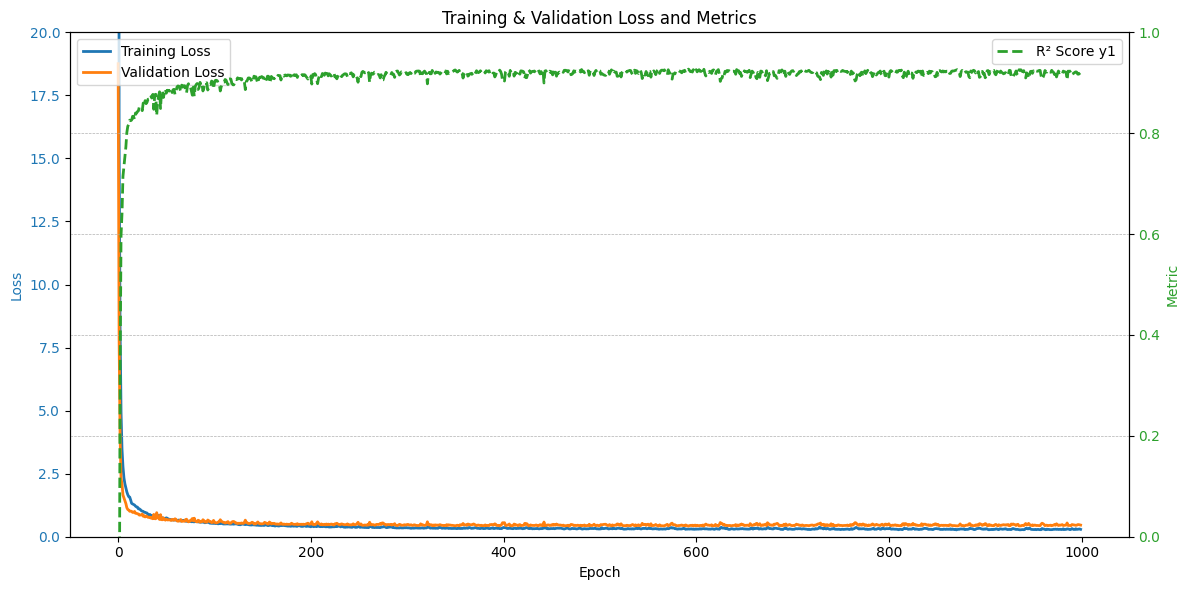

Training completed for TMA_Mango2_optimalconditions2. Final path: C:\Users\localadmin\Documents\Progetti\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\DOE2_TMA_Mango_N117_best.pth
tensor([0.4222])
CCC: 0.9471845306831692, R2: 0.9026805758476257, RMSEP: 0.8324960470199585


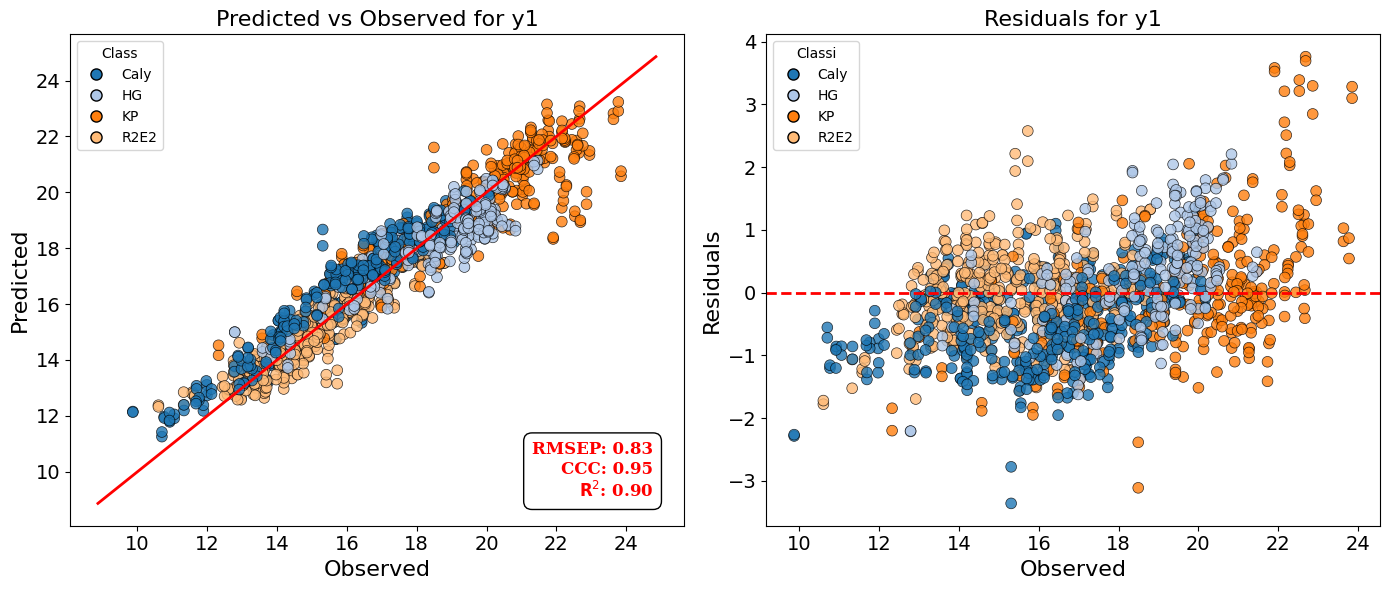

In [85]:

model_name = "TMA_Mango2_optimalconditions2"
config.model_name = model_name
model = TMA_net(
        input_dims=X_cal_std.shape[2],
        input_channel=X_cal_std.shape[1],
        kernel_size= 3,
        aggregation_mode= "avg",
        n_filters= 1,
        kernel_size_aggregation=3,
        fc1_dims= 56,
        dropout= 0.1,
        out_dims=1
    )
config.num_epochs = 1000


optimizer = optim.Adam(model.parameters(), lr=config.learning_rate, weight_decay=0.003/2)
criterion = nn.MSELoss(reduction='none')
print(model)

trainer = Trainer(
        model=model,
        optimizer=optimizer,
        criterion=criterion,
        train_loader=cal_loader3,
        val_loader=val_loader3,
        config=config,
        r_metric='r2',
        verbose=True,
    )
train_losses, val_losses,val_r2_scores, final_path = trainer.train()
print(f"Training completed for {model_name}. Final path: {final_path}")

print(min(val_losses))
utils.test(model, final_path, test_loader3,config, Residual=True,  classes = test_df[ "Cultivar"] )


TMA_net(
  (dropout): Dropout(p=0.1, inplace=False)
  (conv1d): Conv1d(6, 6, kernel_size=(3,), stride=(1,), padding=same, groups=6)
  (aggregate_block): channel_mean()
  (fc1): Linear(in_features=206, out_features=56, bias=True)
  (fc2): Linear(in_features=56, out_features=28, bias=True)
  (fc3): Linear(in_features=28, out_features=14, bias=True)
  (norm): LayerNorm((6, 206), eps=1e-05, elementwise_affine=True)
  (output_layer): Linear(in_features=14, out_features=1, bias=True)
)
Saving best model to C:\Users\localadmin\Documents\Progetti\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\Train_Mango_best.pth
Epoch 1/1000 | Train Loss: 92.2008 | Val Loss: 10.2044 | Val Mean Metrics: -0.7616
Model saved at epoch 0 to C:\Users\localadmin\Documents\Progetti\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\Train_Mango_best.pth
Model saved at epoch 0 to C:\Users\localadmin\Documents\Progetti\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\Train_Mango

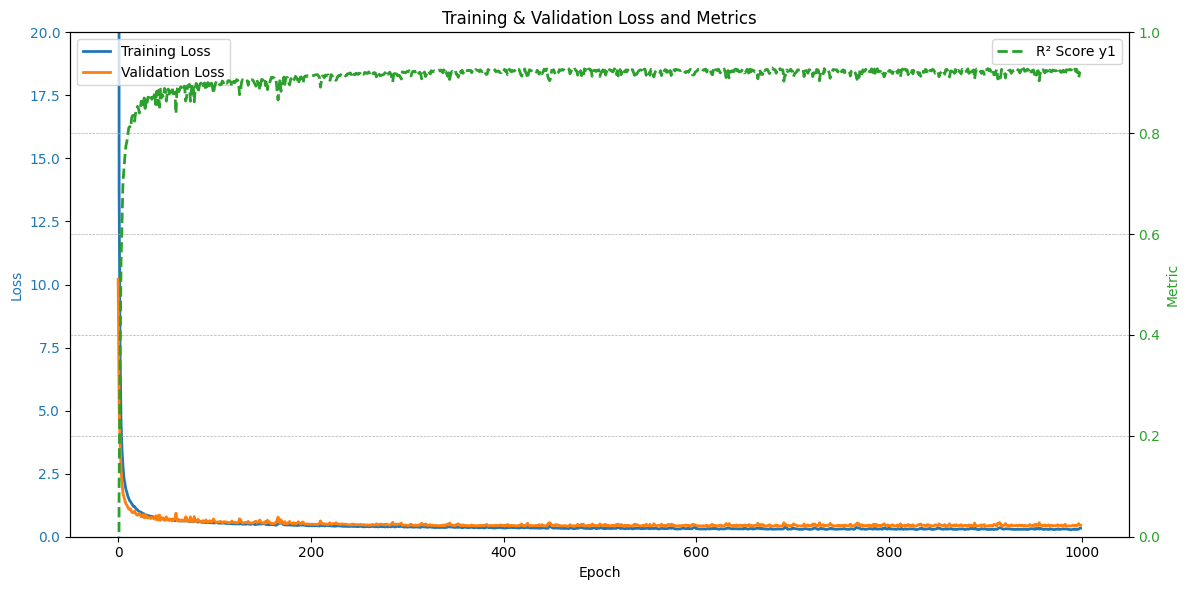

Training completed for TMA_Mango2_optimalconditions. Final path: C:\Users\localadmin\Documents\Progetti\Post_DOC\Lavori\Preprocessing_project\Deep-Chemometrics\models\Train_Mango_best.pth
tensor([0.4086])
CCC: 0.9432737210144299, R2: 0.8987795114517212, RMSEP: 0.8490175604820251


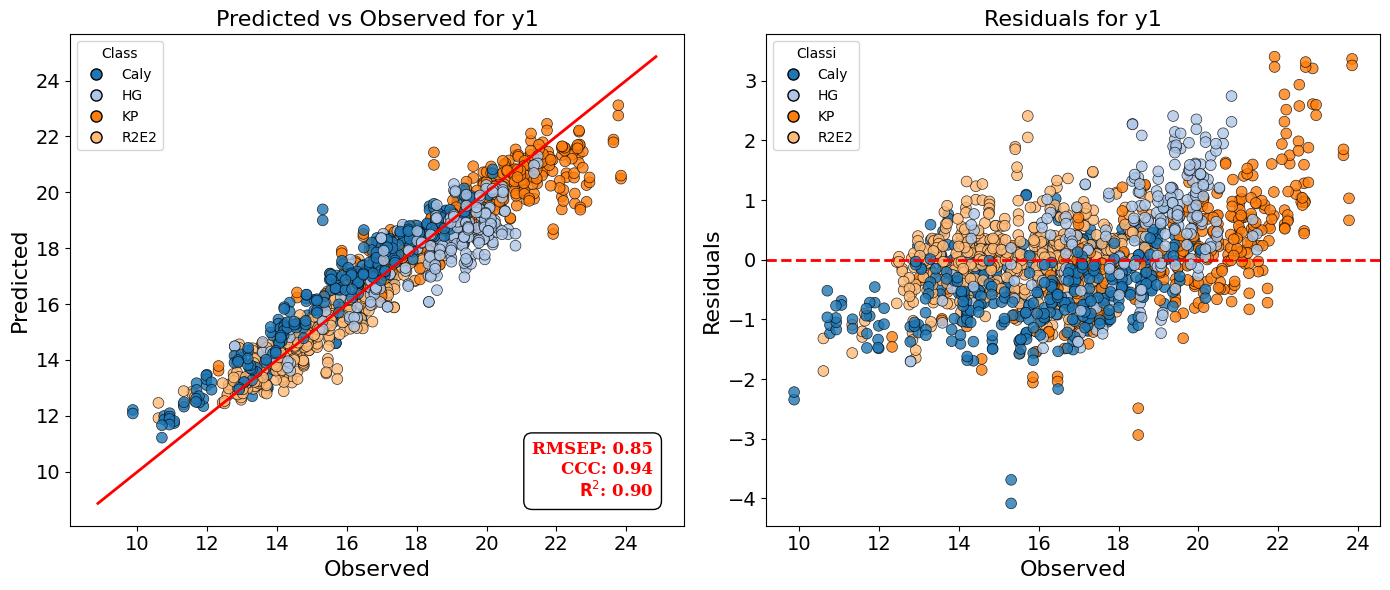

In [119]:
model_name = "TMA_Mango2_optimalconditions"
config.model_name = model_name
model2 = TMA_net(
        input_dims=X_cal_std.shape[2],
        input_channel=X_cal_std.shape[1],
        kernel_size= 3,
        aggregation_mode= "avg",
        n_filters= 1,
        kernel_size_aggregation=3,
        fc1_dims= 56,
        dropout= 0.1,
        out_dims=1
    )


config.num_epochs = 1000



optimizer = optim.Adam(model2.parameters(), lr=config.learning_rate, weight_decay=0.003/2)
criterion = nn.MSELoss(reduction='none')
print(model2)

trainer = Trainer(
        model=model2,
        optimizer=optimizer,
        criterion=criterion,
        train_loader=cal_loader3,
        val_loader=val_loader3,
        config=config,
        r_metric='r2',
        verbose=True,
    )
train_losses, val_losses,val_r2_scores, final_path = trainer.train()
print(f"Training completed for {model_name}. Final path: {final_path}")

print(min(val_losses))
utils.test(model2, final_path, test_loader3,config, Residual=True,  classes = test_df[ "Cultivar"] )

In [55]:
total = 0
print("Number of parameters :")
for nom, param in model2.named_parameters():
    if param.requires_grad:
        nb_params = param.numel()
        print(f"{nom}: {nb_params}")
        total += nb_params

print(f"\n Total number of parameters : {total}")

Number of parameters :
conv1d.weight: 18
conv1d.bias: 6
fc1.weight: 11536
fc1.bias: 56
fc2.weight: 1568
fc2.bias: 28
fc3.weight: 392
fc3.bias: 14
norm.weight: 1236
norm.bias: 1236
output_layer.weight: 14
output_layer.bias: 1

 Total number of parameters : 16105


In [113]:
import numpy as np
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.metrics import make_scorer, mean_squared_error
from scipy.signal import savgol_filter

# --- Transformer SG (derivata seconda) su righe=campioni, colonne=variabili ---
def sg_deriv2(X, window_length=13, polyorder=2, deriv=2):
    # window_length deve essere dispari e >= polyorder+1
    return savgol_filter(X, window_length=window_length, polyorder=polyorder,
                         deriv=deriv, axis=1)

sg = FunctionTransformer(sg_deriv2, kw_args={"window_length":13, "polyorder":2, "deriv":2})

# --- Pipeline: SG -> StandardScaler -> PLS ---
pipe = Pipeline(steps=[
    ("sg", sg),
    ("scaler", StandardScaler(with_std = False, with_mean=True)),
    ("pls", PLSRegression(scale=False))  # scale=False perché già standardizziamo
])

# --- Griglia iperparametri ---

param_grid = {
    "sg__kw_args": [ {"window_length":13, "polyorder":2, "deriv":1},
                     {"window_length":13, "polyorder":2, "deriv":2}],
   "pls__n_components": list(range(1, 20))
}


# Scorer (RMSECV minimizzato -> usare neg MSE da massimizzare)
rmse_scorer = make_scorer(lambda y, yhat: np.sqrt(np.mean((y - yhat)**2)), greater_is_better=False)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

gscv = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring=rmse_scorer,
    cv=cv,   # <-- evita multiprocessing
    return_train_score=True
)


# ---- Fit su calibrazione ----
gscv.fit(X_cal, y_cal)

print("Migliori parametri:", gscv.best_params_)
print("RMSECV:", np.abs(gscv.best_score_))

# ---- Modello ottimo e predizione su test ----
best_model = gscv.best_estimator_
y_pred = best_model.predict(X_test)


Migliori parametri: {'pls__n_components': 19, 'sg__kw_args': {'window_length': 13, 'polyorder': 2, 'deriv': 1}}
RMSECV: 0.8551218927784452


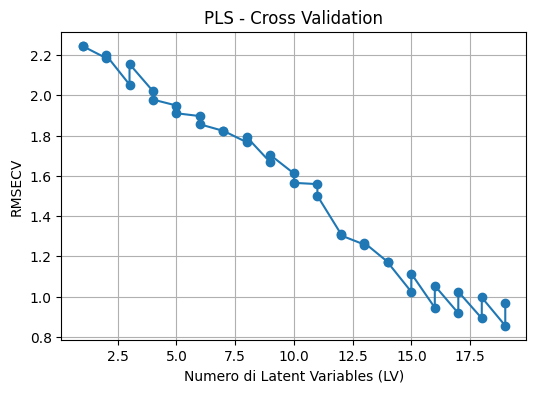

In [115]:
# Estrai i risultati della CV
results = gscv.cv_results_

# Numero di componenti provati
n_comp = results['param_pls__n_components'].data

# RMSECV (negativo nel nostro scorer, quindi invertiamo segno)
rmsecv = -results['mean_test_score']

plt.figure(figsize=(6,4))
plt.plot(n_comp, rmsecv, marker='o')
plt.xlabel('Numero di Latent Variables (LV)')
plt.ylabel('RMSECV')
plt.title('PLS - Cross Validation')
plt.grid(True)
plt.show()


RMSEP: 1.0100


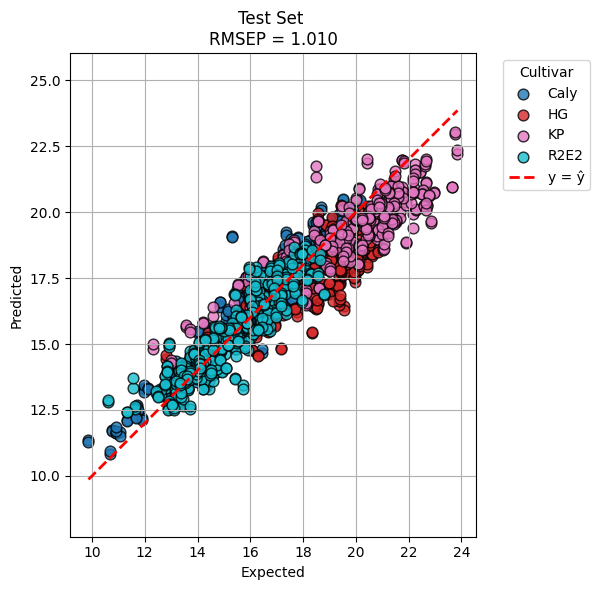

In [116]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

# --- Dati e predizioni ---
y_true = np.ravel(y_test)
y_pred = np.ravel(y_pred)
classes = test_df["Cultivar"].values
unique_classes = np.unique(classes)

# --- Calcola RMSEP ---
rmsep = np.sqrt(mean_squared_error(y_true, y_pred))
print(f"RMSEP: {rmsep:.4f}")

# --- Crea palette colori ---
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_classes)))

plt.figure(figsize=(6,6))

# --- Scatter per ogni classe ---
for cls, color in zip(unique_classes, colors):
    idx = classes == cls
    plt.scatter(y_true[idx], y_pred[idx],
                label=cls, color=color, edgecolor='k', alpha=0.8, s=60)

# --- Linea ideale y = ŷ ---
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         'r--', lw=2, label='y = ŷ')

# --- Etichette e titolo ---
plt.xlabel('Expected')
plt.ylabel('Predicted')
plt.title(f'Test Set \nRMSEP = {rmsep:.3f}')
plt.legend(title='Cultivar', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.show()


Dario NET to do


In [56]:
from src.net import Darionet

model_name = 'DarioNet'
config.model_name = model_name
model = Darionet(mean =  np.mean(X_cal_concat1, axis=0), std = np.std(X_cal_concat1, axis=0) ,filter_size = 45, reg_beta = 0.015, input_dims = X_cal_concat1.shape[1],out_dims=1)
config.num_epochs = 1000
optimizer = optim.Adam(model.parameters(), lr=config.learning_rate, weight_decay=0.015)
criterion = nn.MSELoss(reduction='none')
print(model)

trainer = Trainer(
        model=model,
        optimizer=optimizer,
        criterion=criterion,
        train_loader=cal_loader2,
        val_loader=val_loader2,
        config=config,
        r_metric='r2',
        verbose=True,
    )
train_losses, val_losses,val_r2_scores, final_path = trainer.train()
print(f"Training completed for {model_name}. Final path: {final_path}")
utils.test(model, final_path, test_loader2,config, Residual=True,  classes = test_df[ "Cultivar"] )

NameError: name 'X_cal_concat1' is not defined

In [ ]:
total = 0
print("Nombre de paramètres par couche :")
for nom, param in model.named_parameters():
    if param.requires_grad:
        nb_params = param.numel()
        print(f"{nom}: {nb_params}")
        total += nb_params

print(f"\nNombre total de paramètres : {total}")

Nombre de paramètres par couche :
conv1.weight: 45
conv1.bias: 1
fc1.weight: 158208
fc1.bias: 128
fc2.weight: 8192
fc2.bias: 64
fc3.weight: 1024
fc3.bias: 16
output_layer.weight: 16
output_layer.bias: 1

Nombre total de paramètres : 167695


In [106]:
# --- HOOKS ROBUSTI + ISPEZIONE/PLOT ---

features = {}

def save_hook(name):
    def hook(module, inp, out):
        # supporta Tensor o tuple/list
        t = out if isinstance(out, torch.Tensor) else out[0]
        t = t.detach().cpu()
        features[name] = t
        print(f"{name} -> shape {tuple(t.shape)}")
    return hook

def register_debug_hooks(net):
    """
    Registra gli hook e RESTITUISCE gli handle per poterli rimuovere in seguito.
    """
    features.clear()
    handles = []
    if hasattr(net, "conv1d"):
        handles.append(net.conv1d.register_forward_hook(save_hook("conv1d")))
    if hasattr(net, "norm"):
        handles.append(net.norm.register_forward_hook(save_hook("norm")))
    if hasattr(net, "aggregate_block"):
        handles.append(net.aggregate_block.register_forward_hook(save_hook("aggregate")))
    if hasattr(net, "norm2"):   
        handles.append(net.norm2.register_forward_hook(save_hook("norm2")))

    return handles

def remove_hooks(handles):
    for h in handles:
        try:
            h.remove()
        except Exception:
            pass

def _to_BCL(xb):
    """
    Converte xb in forma [B, C, L].
    Supporta:
      - [B, 1, C, L]  (come TMA_net.forward si aspetta)
      - [B, C, L]
    """
    if xb.ndim == 4:
        # atteso [B,1,C,L] -> squeeze dim=1
        if xb.shape[1] == 1:
            return xb.squeeze(1)
        # se è [B, C, 1, L] o altro, prova ad adattare
        if xb.shape[2] == 1:
            return xb.squeeze(2)
        raise ValueError(f"Input 4D non atteso: {tuple(xb.shape)}. Atteso [B,1,C,L].")
    elif xb.ndim == 3:
        return xb
    else:
        raise ValueError(f"Input con ndim={xb.ndim} non supportato. Attesi 3D o 4D.")

def inspect_and_plot_channels(
    net, loader, device=None, sample_idx=0, max_channels=9,
    same_ylim=True, extra_channels=None
):
    """
    Ogni canale ha un suo subplot.
    Sotto, un subplot extra con l'uscita di aggregate_block.
    """
    import numpy as np
    import matplotlib.pyplot as plt

    if device is None:
        device = next(net.parameters()).device

    net.eval()
    with torch.no_grad():
        xb, yb = next(iter(loader))
        xb = xb.to(device)
        _ = net(xb)  # attiva gli hook

    xb_cpu = xb.detach().cpu()
    xb_bcl = _to_BCL(xb_cpu)  # [B, C, L]
    B, C, L = xb_bcl.shape

    has_conv = ("conv1d" in features) and (features["conv1d"].ndim == 3)
    has_norm = ("norm" in features) and (features["norm"].ndim == 3)
    conv = features["conv1d"] if has_conv else None
    norm = features["norm"] if has_norm else None

    # Adattamento conv per-canale (se depthwise con g filtri per canale -> media sui g)
    conv_per_channel = None
    if has_conv:
        Bc, Cout, Lc = conv.shape
        assert Bc == B and Lc == L, f"Shape conv mismatch: input (B={B},L={L}), conv {tuple(conv.shape)}"
        if Cout == C:
            conv_per_channel = conv  # [B, C, L]
        else:
            assert Cout % C == 0, f"Cout={Cout} non multiplo di C={C}"
            g = Cout // C
            conv_per_channel = conv.view(B, C, g, L).mean(dim=2)  # [B, C, L]

    norm_per_channel = None
    if has_norm:
        Bn, Nout, Ln = norm.shape
        assert Bn == B and Ln == L, f"Shape norm mismatch: input (B={B},L={L}), norm {tuple(norm.shape)}"
        if Nout == C:
            norm_per_channel = norm
        else:
            assert Nout % C == 0, f"Nout={Nout} non multiplo di C={C}"
            g = Nout // C
            norm_per_channel = norm.view(B, C, g, L).mean(dim=2)

    # quanti canali plottare
    n_channels = min(C, max_channels)

    # figura: n_channels subplot per canale + 1 subplot per aggregation
    fig, axes = plt.subplots(n_channels + 1, 1, figsize=(12, 2.5*(n_channels + 1)), sharex=True)
    if n_channels + 1 == 1:
        axes = [axes]
    chan_axes = axes[:n_channels]
    ax_agg = axes[-1]

    # limiti comuni opzionali
    if same_ylim:
        all_y = []
        for c in range(n_channels):
            all_y.append(xb_bcl[sample_idx, c, :].numpy())
            if conv_per_channel is not None:
                all_y.append(conv_per_channel[sample_idx, c, :].numpy())
            if norm_per_channel is not None:
                all_y.append(norm_per_channel[sample_idx, c, :].numpy())
        y_min = min(map(np.min, all_y)) if all_y else None
        y_max = max(map(np.max, all_y)) if all_y else None

    # --- subplot dei canali ---
    for c, ax in enumerate(chan_axes):
        ax.plot(xb_bcl[sample_idx, c, :].numpy(), label=f"in_c{c}")
        ax.set_ylabel("Input (a.u.)", color="C0")
        ax2 = ax.twinx()
        ax2.set_ylabel("CCN (a.u.)", color="C1")


        # conv/norm per canale
        if conv_per_channel is not None and norm_per_channel is None:
            ax2.plot(conv_per_channel[sample_idx, c, :].numpy(), linestyle="--", label=f"conv̄_c{c}", color="C1")
        if norm_per_channel is not None:
            ax2.plot(norm_per_channel[sample_idx, c, :].numpy(), linestyle=":", label=f"norm̄_c{c}", color="C1")

        # extra conv channels grezzi (se richiesti)
        if extra_channels and has_conv:
            for ec in extra_channels:
                if 0 <= ec < conv.shape[1]:
                    ax.plot(conv[sample_idx, ec, :].numpy(), alpha=0.6, label=f"conv[{ec}]")

        if same_ylim and (y_min is not None):
            ax.set_ylim(y_min, y_max)
        ax.legend(fontsize=8, frameon=False)


    # --- subplot AGGREGATION (in basso nella stessa figura) ---
    ax_agg.set_title("Aggregation", fontsize=11)
    if "aggregate" in features:
        agg = features["aggregate"]  # (B, Cagg, Lagg) oppure (B, F)

        if agg.ndim == 3:
            # plottiamo fino a max_channels curve di aggregazione
            Cagg = agg.shape[1]
            n_agg = min(Cagg, max_channels)
            ax_agg.set_ylabel("Input (a.u.)", color="C0")
            ax_agg.plot(xb_bcl[sample_idx,0,:].numpy(), color="C0", alpha=0.3, linestyle="-", label="input mean")
            ax_agg2 = ax_agg.twinx()

            for c in range(n_agg):
                ax_agg2.plot(agg[sample_idx, c, :].numpy(), label=f"agg_c{c}", linestyle="--", color="C1")
            # opzionale: media dell'input per confronto
            ax_agg2.set_ylabel("agg (a.u.)", color="C1")
            ax_agg2.legend(fontsize=8, frameon=False)

        elif agg.ndim == 2:
            # vettore feature 1D
            ax_agg.plot(agg[sample_idx].numpy(), label="aggregate")
            ax_agg.set_ylabel("agg (feat)")
            ax_agg.legend(fontsize=8, frameon=False)
    else:
        ax_agg.text(0.5, 0.5, "Nessun output 'aggregate' catturato", ha="center", va="center", transform=ax_agg.transAxes)
        ax_agg.set_axis_off()
        chan_axes[-1].set_xlabel("indice")


    plt.tight_layout()
    plt.show()

    return fig

conv1d -> shape (1024, 6, 206)
norm -> shape (1024, 6, 206)
aggregate -> shape (1024, 1, 206)


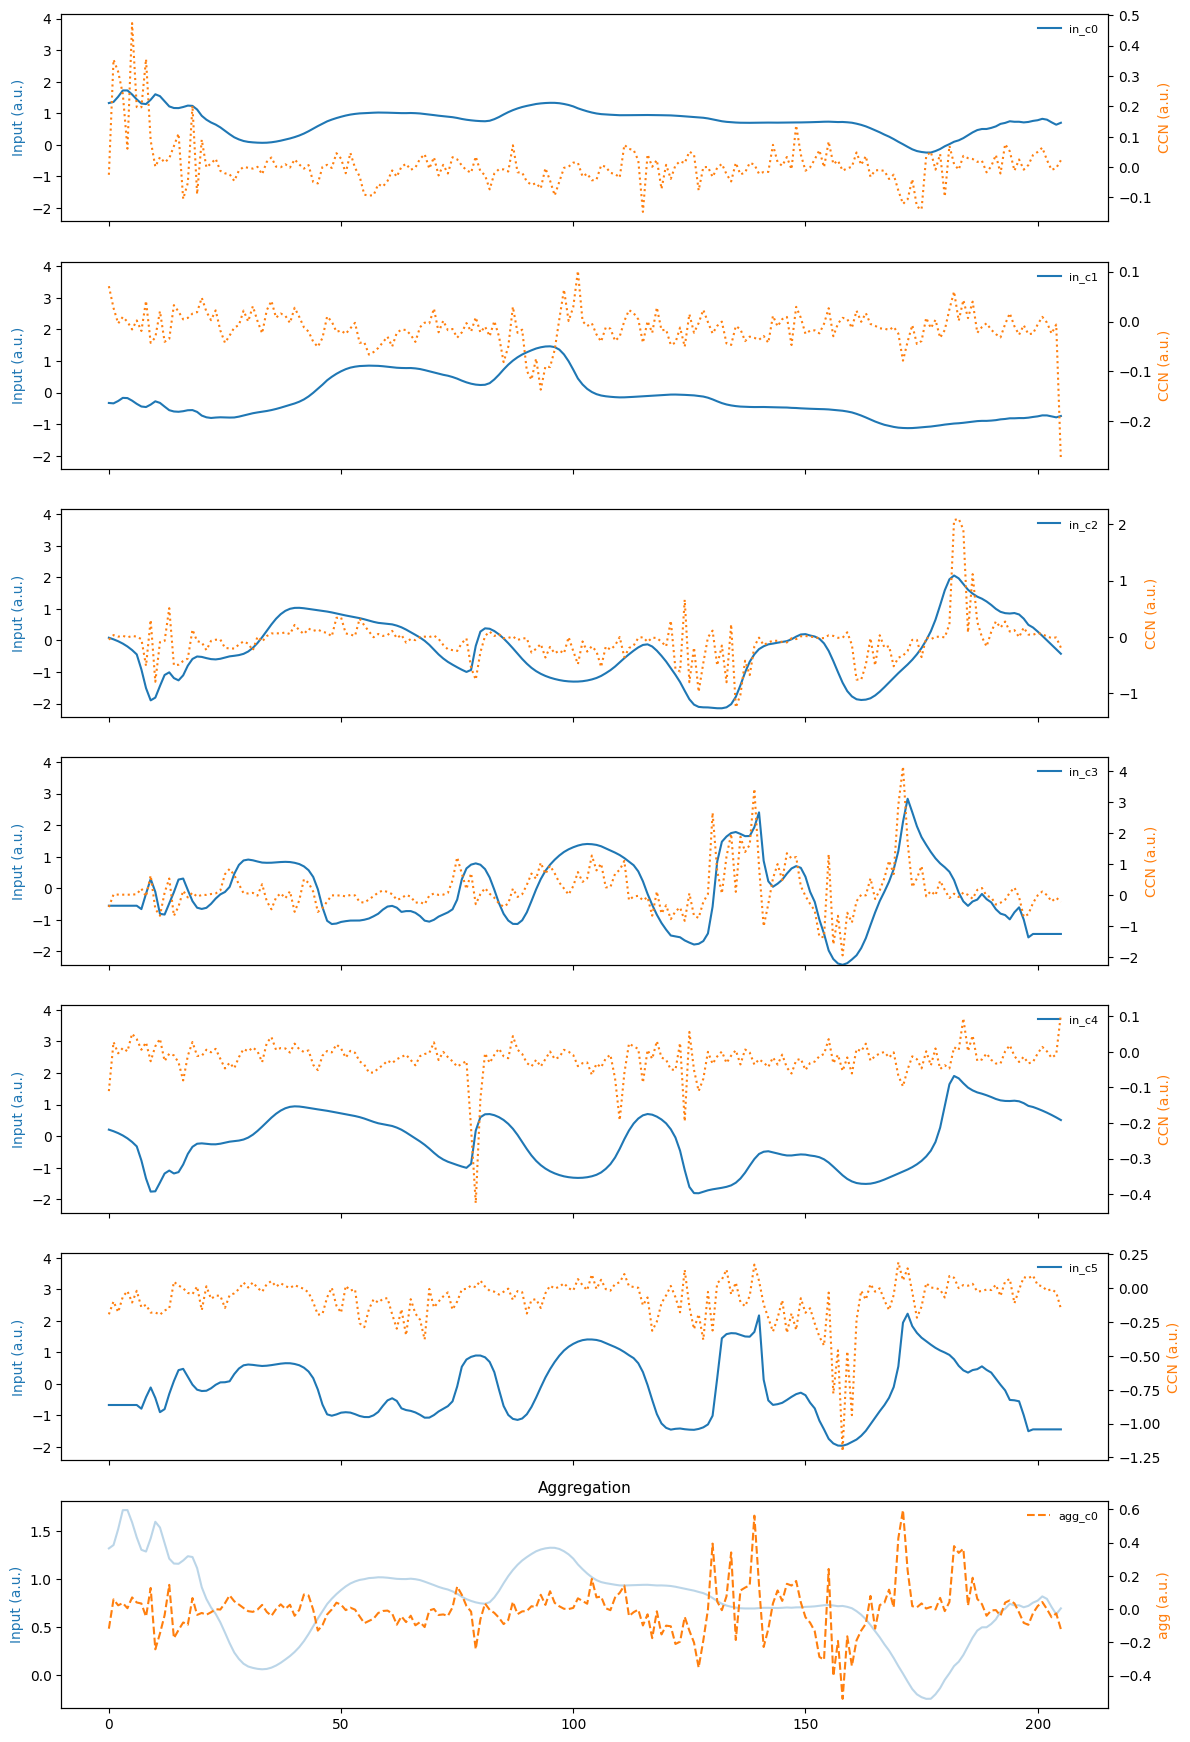

In [121]:
# 1) carica il modello allenato
# model2 = TMA_net(...); model2.load_state_dict(torch.load("best.pt")); model2.eval()


# 2) registra hook
handles = register_debug_hooks(model2)

# 3) ispeziona e plottA
inspect_and_plot_channels(
    model2,
    test_loader3,
    sample_idx=100,
    max_channels=9,
    same_ylim=True,
    extra_channels=None  # opzionale
)

# 4) rimuovi gli hook
remove_hooks(handles)
